# Compas Analysis

What follows are the calculations performed for ProPublica's analysis of the COMPAS Recidivism Risk Scores. It might be helpful to open [the methodology](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) in another tab to understand the following.

## Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)
print(raw_data.shape[0])

7214


In [2]:
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


However not all of the rows are useable for the first round of analysis.

There are a number of reasons remove rows because of missing data:
* If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a compas case at all.
* In a similar vein, ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in Jail time are removed (only two of them).
* We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

In [3]:
# Data Preparation for Modeling (COMPAS Dataset)

# Select relevant features for modeling
# These variables capture demographic attributes, criminal history,
# and COMPAS risk scores used in the analysis.
df = raw_data[[
    "age", "c_charge_degree", "race", "age_cat",
    "score_text", "sex", "priors_count",
    "days_b_screening_arrest", "decile_score", "is_recid",
    "two_year_recid", "c_jail_in", "c_jail_out"
]].copy()

# ── Filtering ────────────────────────────────────────────────────
df = df[df["days_b_screening_arrest"].between(-30, 30)]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
df = df[df["score_text"] != "N/A"]
df = df.reset_index(drop=True)

# ── Type conversions ─────────────────────────────────────────────
for col in ["c_jail_in", "c_jail_out"]:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S", utc=True)

# ── Derived factors with reference levels ─────────────────────────
df["crime_factor"] = pd.Categorical(df["c_charge_degree"])

df["age_factor"] = pd.Categorical(
    df["age_cat"],
    categories=["25 - 45", "Less than 25", "Greater than 45"]
)

df["race_factor"] = pd.Categorical(
    df["race"],
    categories=["Caucasian", "African-American", "Asian", "Hispanic", "Native American", "Other"]
)

df["gender_factor"] = pd.Categorical(
    df["sex"],
    categories=["Male", "Female"]
)

df["score_factor"] = pd.Categorical(
    np.where(df["score_text"] != "Low", "HighScore", "LowScore"),
    categories=["LowScore", "HighScore"]
)

print(f"Number of observations after filtering: {len(df)}")

Number of observations after filtering: 6172


In [4]:
df.head()

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,LowScore
3,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,LowScore
4,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,HighScore


In [5]:
# Similar to glimpse(df) in R, but also shows null counts and memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6172 entries, 0 to 6171
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   age                      6172 non-null   int64              
 1   c_charge_degree          6172 non-null   object             
 2   race                     6172 non-null   object             
 3   age_cat                  6172 non-null   object             
 4   score_text               6172 non-null   object             
 5   sex                      6172 non-null   object             
 6   priors_count             6172 non-null   int64              
 7   days_b_screening_arrest  6172 non-null   float64            
 8   decile_score             6172 non-null   int64              
 9   is_recid                 6172 non-null   int64              
 10  two_year_recid           6172 non-null   int64              
 11  c_jail_in                6172 

Higher COMPAS scores are slightly correlated with a longer length of stay.

In [6]:
# Feature Engineering: Length of Stay
df["length_of_stay"] = (
    df["c_jail_out"].dt.normalize() - df["c_jail_in"].dt.normalize()
).dt.days

# Exploratory Analysis: Relationship with Risk Score

corr = df[["length_of_stay", "decile_score"]].dropna().corr()

# Extract correlation coefficient
correlation_value = corr.loc["length_of_stay", "decile_score"]
print(correlation_value)


0.20732969161470416


After filtering we have the following demographic breakdown:

In [7]:
# This is equivalent to R's summary(df$age_cat).
df["age_cat"].value_counts()

,count
age_cat,
25 - 45,3532
Less than 25,1347
Greater than 45,1293


From the initial 7,214 records, 6,172 valid observations were retained after applying data quality filters, resulting in approximately 14.5% of the data being removed. The resulting dataset exhibits a notable racial imbalance, with 51.4% Black defendants and 34.1% White defendants, which is an important consideration in bias analysis.

Within the final sample, 45.5% of individuals reoffended within two years, providing the baseline recidivism rate for the model. The sample is also predominantly male (81%), with females representing 19%, and the majority of individuals fall within the 25–45 age range.

In [9]:
# This is equivalent to R's summary(df$race)
df["race"].value_counts()

,count
race,
African-American,3175
Caucasian,2103
Hispanic,509
Other,343
Asian,31
Native American,11


In [10]:
# Compute the percentage representation of each racial group
n_total = len(df)
races = [
    ("Black defendants",           "African-American"),
    ("White defendants",           "Caucasian"),
    ("Hispanic defendants",        "Hispanic"),
    ("Asian defendants",           "Asian"),
    ("Native American defendants", "Native American"),
]
for label, race in races:
    pct = (df["race"] == race).sum() / n_total * 100
    print(f"{label}: {pct:.2f}%")

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [11]:
# This is equivalent to R's summary(df$score_text)
print(df["score_text"].value_counts())

score_text
Low       3421
Medium    1607
High      1144
Name: count, dtype: int64


In [12]:
# This is equivalent to R's xtabs(~ sex + race, data=df)
print(pd.crosstab(df["sex"], df["race"]))

race    African-American  Asian  Caucasian  Hispanic  Native American  Other
sex                                                                         
Female               549      2        482        82                2     58
Male                2626     29       1621       427                9    285


In [13]:
# This is equivalent to R's summary(df$sex)
df["sex"].value_counts()

,count
sex,
Male,4997
Female,1175


In [14]:
# Compute the percentage representation of each gender group
print("Men: %.2f%%"   % ((df["sex"] == "Male").sum()   / n_total * 100))
print("Women: %.2f%%" % ((df["sex"] == "Female").sum() / n_total * 100))

Men: 80.96%
Women: 19.04%


In [15]:
# This is equivalent to R's nrow(filter(df, two_year_recid == 1))
print((df["two_year_recid"] == 1).sum())

2809


In [16]:
# Compute the percentage of defendants who reoffended within
print((df["two_year_recid"] == 1).sum() / len(df) * 100)

45.51198963058976


Data Composition and Potential Sources of Bias
From the initial 7,214 records, 6,172 observations remained after applying data quality filters, indicating that approximately 14.5% of the data was excluded. The resulting dataset is notably imbalanced by race, with 51.4% Black defendants compared to 34.1% White defendants, which is an important consideration when assessing potential bias.

In this sample, 45.5% of individuals recidivated within two years, providing the baseline outcome rate for the model. The dataset is also predominantly male (81%), with females accounting for 19%, and most individuals fall within the 25–45 age group.

Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

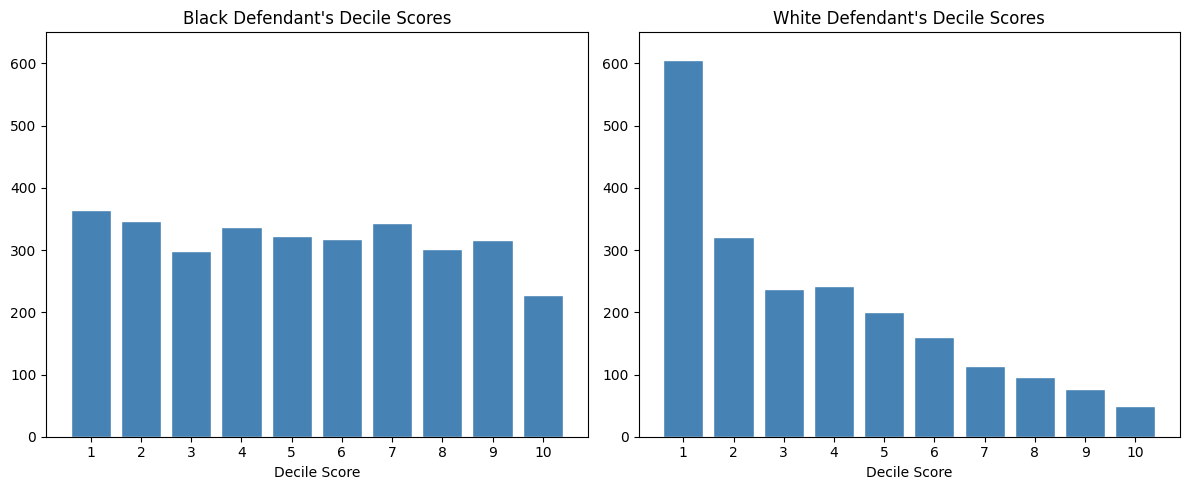

In [17]:
# Visualize the distribution of COMPAS decile scores separately
# for Black and White defendants
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, race, title in [
    (axes[0], "African-American", "Black Defendant's Decile Scores"),
    (axes[1], "Caucasian",        "White Defendant's Decile Scores"),
]:
    counts = (
        df[df["race"] == race]["decile_score"]
        .value_counts()
        .reindex(range(1, 11), fill_value=0)
        .sort_index()
    )
    ax.bar(counts.index, counts.values, color="steelblue", edgecolor="white")
    ax.set_xlabel("Decile Score")
    ax.set_ylim(0, 650)
    ax.set_title(title)
    ax.set_xticks(range(1, 11))

plt.tight_layout()
plt.show()

In [19]:
# This is equivalent to R's  xtabs(~ decile_score + race, data=df)
pd.crosstab(df["decile_score"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


## Racial Bias in Compas

After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. To do so we need to change some variables into factors, and run a logistic regression, comparing low scores to high scores.

In [20]:
# Modeling: Logistic Regression (Interpretable Model)

# Fit a logistic regression model to predict whether a defendant
# receives a high COMPAS risk score (HighScore vs LowScore).
# This mirrors glm(..., family = binomial(link = 'logit') in R.
# Dependent variable: binary risk score (0 = LowScore, 1 = HighScore)
df["score_binary"] = (df["score_text"] != "Low").astype(int)

model_glm = smf.logit(
    "score_binary ~ gender_factor + age_factor + race_factor + priors_count + crime_factor + two_year_recid",
    data=df
).fit()

print(model_glm.summary())

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Mon, 06 Apr 2026   Pseudo R-squ.:                  0.2729
Time:                        11:21:36   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                          -1.5255      0.079    -19.430  

Model Fit and Evidence of Racial Bias

The pseudo R² value of 0.273 suggests a moderate level of model performance, indicating that the model explains a meaningful share of the variation in outcomes, though it is not fully predictive.

Importantly, race remains statistically significant (p < 0.001) even after accounting for prior offenses and actual recidivism. This indicates that the observed effect is unlikely to be explained solely by differences in criminal history, pointing instead to potential bias within the model.

Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [21]:
# Model Interpretation: Relative Risk by Race

# Compute the relative risk of being classified as high risk
# for African-American defendants compared to Caucasian defendants.
# This is derived from the logistic regression coefficients.

intercept = model_glm.params["Intercept"]
coef_race  = model_glm.params["race_factor[T.African-American]"]

control = np.exp(intercept) / (1 + np.exp(intercept))
relative_risk_race = np.exp(coef_race) / (1 - control + control * np.exp(coef_race))
print(f"Relative risk (African-American vs Caucasian): {relative_risk_race:.6f}")

Relative risk (African-American vs Caucasian): 1.452837


Women are 19.4% more likely than men to get a higher score.

In [22]:
# Model Interpretation: Relative Risk by Gender

# Compute the relative risk of being classified as high risk
# for Female defendants compared to Male defendants.
coef_gender = model_glm.params["gender_factor[T.Female]"]
relative_risk_gender = np.exp(coef_gender) / (1 - control + control * np.exp(coef_gender))
print(f"Relative risk (Female vs Male): {relative_risk_gender:.6f}")

Relative risk (Female vs Male): 1.194795


Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

In [23]:
# Model Interpretation: Relative Risk by Age

# Compute the relative risk of being classified as high risk
# for defendants younger than 25 compared to the reference group (25–45).
coef_age = model_glm.params["age_factor[T.Less than 25]"]
relative_risk_age = np.exp(coef_age) / (1 - control + control * np.exp(coef_age))
print(f"Relative risk (Less than 25 vs 25-45): {relative_risk_age:.6f}")

Relative risk (Less than 25 vs 25-45): 2.496120


In [24]:
# Model Predictions

df["pred_prob"]  = model_glm.predict(df)
df["pred_class"] = np.where(df["pred_prob"] >= 0.5, "Recid", "No Recid")

In [25]:
# Model Evaluation: Overall Confusion Matrix
print("\n── Overall Confusion Matrix ──────────────────────────────────────────")

overall_cm = pd.crosstab(
    pd.Categorical(df["pred_class"], categories=["No Recid", "Recid"]),
    df["two_year_recid"],
    rownames=["Predicted"],
    colnames=["Actual"]
)
print(overall_cm)

TP = overall_cm.loc["Recid",    1]
TN = overall_cm.loc["No Recid", 0]
FP = overall_cm.loc["Recid",    0]
FN = overall_cm.loc["No Recid", 1]
n  = overall_cm.values.sum()

print(f"\nAccuracy  : {(TP + TN) / n:.3f}")
print(f"Precision : {TP / (TP + FP):.3f}")
print(f"Recall    : {TP / (TP + FN):.3f}")
print(f"FPR       : {FP / (FP + TN):.3f}")
print(f"FNR       : {FN / (FN + TP):.3f}")


── Overall Confusion Matrix ──────────────────────────────────────────
Actual        0     1
Predicted            
No Recid   2653   945
Recid       710  1864

Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


In [26]:
# Model Evaluation: Confusion Matrix by Race

print("\n\n── Confusion Matrix by Race ──────────────────────────────────────────")

def race_metrics_fn(group):
    actual = group["two_year_recid"].astype(int)
    pred   = (group["pred_class"] == "Recid").astype(int)
    TP = int(((pred == 1) & (actual == 1)).sum())
    TN = int(((pred == 0) & (actual == 0)).sum())
    FP = int(((pred == 1) & (actual == 0)).sum())
    FN = int(((pred == 0) & (actual == 1)).sum())
    n  = len(group)
    return pd.Series({
        "n":         n,
        "TP":        TP,
        "TN":        TN,
        "FP":        FP,
        "FN":        FN,
        "Accuracy":  round((TP + TN) / n,           3),
        "Precision": round(TP / (TP + FP),           3) if (TP + FP) > 0 else float("nan"),
        "Recall":    round(TP / (TP + FN),           3) if (TP + FN) > 0 else float("nan"),
        "FPR":       round(FP / (FP + TN),           3) if (FP + TN) > 0 else float("nan"),
        "FNR":       round(FN / (FN + TP),           3) if (FN + TP) > 0 else float("nan"),
    })

race_metrics = (
    df.groupby("race", observed=True)
      .apply(race_metrics_fn)
      .reset_index()
      .sort_values("n", ascending=False)
      .reset_index(drop=True)
)
print(race_metrics.to_string(index=False))



── Confusion Matrix by Race ──────────────────────────────────────────
            race      n     TP     TN    FP    FN  Accuracy  Precision  Recall   FPR   FNR
African-American 3175.0 1373.0  959.0 555.0 288.0     0.734      0.712   0.827 0.367 0.173
       Caucasian 2103.0  381.0 1148.0 133.0 441.0     0.727      0.741   0.464 0.104 0.536
        Hispanic  509.0   81.0  306.0  14.0 108.0     0.760      0.853   0.429 0.044 0.571
           Other  343.0   22.0  216.0   3.0 102.0     0.694      0.880   0.177 0.014 0.823
           Asian   31.0    2.0   22.0   1.0   6.0     0.774      0.667   0.250 0.043 0.750
 Native American   11.0    5.0    2.0   4.0   0.0     0.636      0.556   1.000 0.667 0.000


In [27]:
# Fairness Analysis: FPR and FNR Disparity by Race

print("\n\n── FPR and FNR Disparity by Race ─────────────────────────────────────")

caucasian_row = race_metrics[race_metrics["race"] == "Caucasian"].iloc[0]
ref_fpr = caucasian_row["FPR"]
ref_fnr = caucasian_row["FNR"]

disparity = race_metrics[["race", "n", "FPR", "FNR"]].copy()
disparity["delta_FPR"] = (disparity["FPR"] - ref_fpr).round(3)
disparity["delta_FNR"] = (disparity["FNR"] - ref_fnr).round(3)

print(disparity.to_string(index=False))



── FPR and FNR Disparity by Race ─────────────────────────────────────
            race      n   FPR   FNR  delta_FPR  delta_FNR
African-American 3175.0 0.367 0.173      0.263     -0.363
       Caucasian 2103.0 0.104 0.536      0.000      0.000
        Hispanic  509.0 0.044 0.571     -0.060      0.035
           Other  343.0 0.014 0.823     -0.090      0.287
           Asian   31.0 0.043 0.750     -0.061      0.214
 Native American   11.0 0.667 0.000      0.563     -0.536


Fairness Interpretation

The model exhibits unequal false positive and false negative rates across racial groups, indicating disparities in its predictive performance.

In particular, a higher false positive rate for Black defendants suggests they are more likely to be incorrectly labeled as high risk, potentially resulting in more severe consequences.

This leads to a critical governance question: which type of error carries greater harm, and for which groups?

Overall, these findings highlight that maximizing predictive accuracy alone does not ensure fairness or equity in outcomes.

Conclusion

The analysis provides empirical evidence that COMPAS is not a neutral predictive system, as it reflects racial and age-related biases that cannot be fully attributed to differences in criminal history.

From a Responsible Machine Learning standpoint, this illustrates a case of proxy discrimination, where race functions as an independently influential factor, thereby violating fairness criteria such as Equalized Odds, which requires equal false positive and false negative rates across groups.

Ultimately, the model prioritizes overall predictive accuracy while disproportionately affecting minority populations.

# Assignment 2
**Coding: Explaining the COMPAS Replacement Model**

In [28]:
# STEP 0 — Define features + Train/test split

from sklearn.model_selection import train_test_split

# Define features
numeric_features  = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
category_features = ["age_cat", "sex", "race", "c_charge_degree", "score_text"]
target            = "two_year_recid"
features          = numeric_features + category_features

X = df[features]
y = df[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (4937, 9), Test: (1235, 9)


In [29]:
# STEP 1 — Fit Logistic Regression and Gradient-Boosted Tree

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), category_features),
])

# Logistic regression (GLM — interpretable by design)
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])
lr_pipeline.fit(X_train, y_train)

# Gradient-boosted tree (black-box)
gbt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200, max_depth=4, random_state=42))
])
gbt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'priors_count',
                                                   'days_b_screening_arrest',
                                                   'decile_score']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['age_cat', 'sex', 'race',
                                                   'c_charge_degree',
                                                   'score_text'])])),
                ('classifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=200,
                                            random_state=42))])

In [30]:
# STEP 2 — Compare model performance by race
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

def group_metrics(pipeline, X, y, group_col="race"):
    results = []
    X_ = X.copy()
    X_["actual"]    = y.values
    X_["pred"]      = pipeline.predict(X)
    X_["pred_prob"] = pipeline.predict_proba(X)[:, 1]
    for group, gdf in X_.groupby(group_col):
        cm = confusion_matrix(gdf["actual"], gdf["pred"], labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        results.append({
            "race":     group,
            "n":        len(gdf),
            "accuracy": round(accuracy_score(gdf["actual"], gdf["pred"]), 3),
            "FPR":      round(fp / (fp + tn), 3) if (fp + tn) > 0 else float("nan"),
            "FNR":      round(fn / (fn + tp), 3) if (fn + tp) > 0 else float("nan"),
            "AUC":      round(roc_auc_score(gdf["actual"], gdf["pred_prob"]), 3),
        })

    return pd.DataFrame(results).sort_values("n", ascending=False)

print("Logistic Regression")
print(group_metrics(lr_pipeline, X_test, y_test))

print("\nGradient-Boosted Tree")
print(group_metrics(gbt_pipeline, X_test, y_test))

Logistic Regression
               race    n  accuracy    FPR    FNR    AUC
0  African-American  641     0.691  0.296  0.320  0.758
2         Caucasian  427     0.696  0.128  0.596  0.696
3          Hispanic   94     0.617  0.122  0.667  0.598
5             Other   65     0.785  0.064  0.611  0.789
1             Asian    7     0.857  0.000  1.000  1.000
4   Native American    1     1.000  0.000    NaN    NaN

Gradient-Boosted Tree
               race    n  accuracy    FPR    FNR    AUC
0  African-American  641     0.690  0.322  0.300  0.744
2         Caucasian  427     0.710  0.143  0.534  0.714
3          Hispanic   94     0.660  0.122  0.578  0.648
5             Other   65     0.723  0.106  0.722  0.746
1             Asian    7     0.857  0.000  1.000  0.833
4   Native American    1     1.000  0.000    NaN    NaN


# 1. Compute SHAP values for your model on the test set. Produce: (a) a beeswarm summary plot, (b) a waterfall plot for the highest-risk and lowest-risk defendant in each racial group.

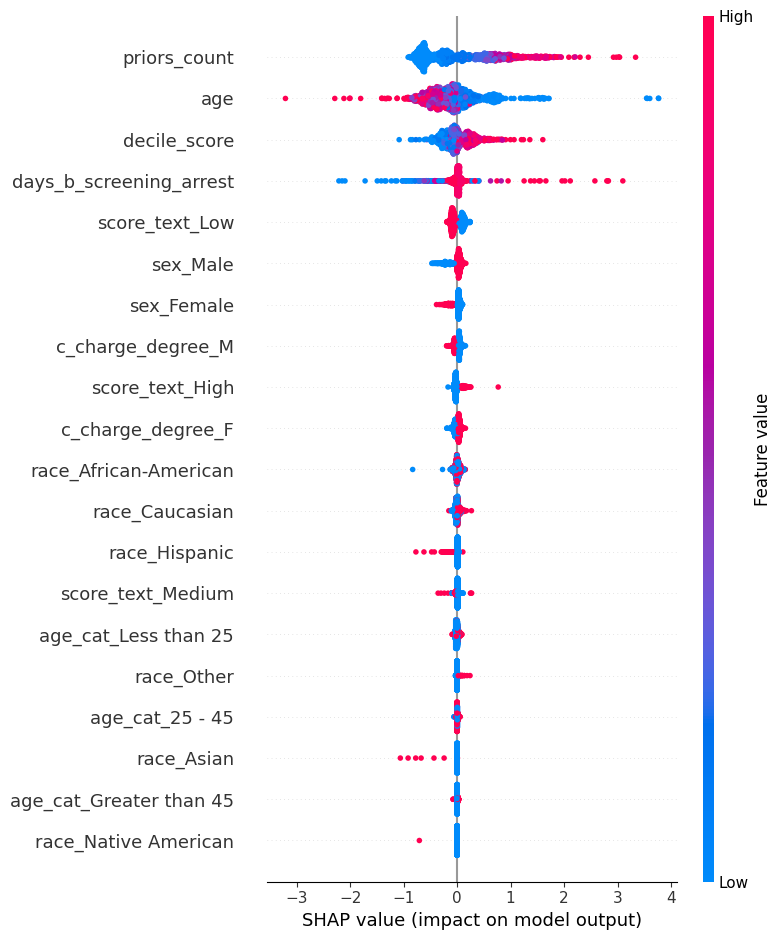

In [31]:
# STEP 4 — SHAP: Beeswarm
##!pip install shap
import shap

# Feature names after encoding
feat_names = (
    numeric_features +
    list(preprocessor.named_transformers_["cat"]
         .get_feature_names_out(category_features))
)

X_test_enc = preprocessor.transform(X_test)

explainer_shap = shap.Explainer(
    gbt_pipeline["classifier"],
    shap.maskers.Independent(X_test_enc, max_samples=100)
)
shap_values = explainer_shap(X_test_enc, check_additivity=False)

# (a) Global beeswarm summary plot
shap.summary_plot(shap_values, X_test_enc, feature_names=feat_names)

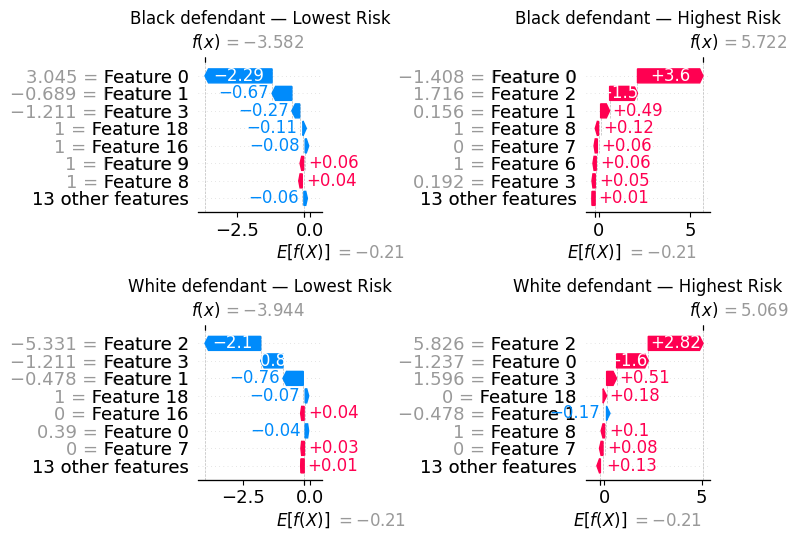

In [32]:
# STEP 4 — Waterfall for 4 individuals
# (b) Waterfall plots for the 4 individuals (homework requirement)
# Predicted probabilities on test set
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob

# Select the 4 individuals required by the homework:
# highest-risk and lowest-risk defendant in each racial group
black_subset = X_test_copy[X_test_copy["race"] == "African-American"].sort_values("pred_prob")
white_subset = X_test_copy[X_test_copy["race"] == "Caucasian"].sort_values("pred_prob")

black_low_idx  = black_subset.index[0]            # lowest risk Black
black_high_idx = black_subset.index[-1]           # highest risk Black
white_low_idx  = white_subset.index[0]            # lowest risk White
white_high_idx = white_subset.index[-1]           # highest risk White

individuals = [
    ("Black defendant — Lowest Risk",  black_low_idx),
    ("Black defendant — Highest Risk", black_high_idx),
    ("White defendant — Lowest Risk",  white_low_idx),
    ("White defendant — Highest Risk", white_high_idx),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for ax, (label, idx) in zip(axes, individuals):
    loc = X_test.index.get_loc(idx)
    plt.sca(ax)
    shap.waterfall_plot(shap_values[loc], max_display=8, show=False)
    ax.set_title(label)


plt.tight_layout()
plt.show()

#2. Run LIME on the same four individuals. Compare LIME and SHAP feature attributions. Where do they agree? Where do they diverge?What does divergence imply for governance?


In [33]:
# STEP 3 — LIME: 4 individuals (highest/lowest risk per racial group)
# Select the 4 individuals required by the homework: highest-risk and lowest-risk defendant in each racial group
!pip install lime
from lime.lime_tabular import LimeTabularExplainer

X_train_enc = preprocessor.fit_transform(X_train)



# Build LIME explainer
explainer = LimeTabularExplainer(
    training_data         = X_train_enc,
    feature_names         = feat_names,
    class_names           = ["NoRecid", "Recid"],
    mode                  = "classification",
    discretize_continuous = True,
    random_state          = 42
)





     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=4c60eb833496a57fc4d377805da68ef94546a76c68574ba9888ed44dfe18357f
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [34]:
# Store median-risk indices for DiCE (Step 5)
black_idx = black_subset.index[len(black_subset) // 2]
white_idx = white_subset.index[len(white_subset) // 2]

# Generate LIME explanations for all 4 individuals
individuals = [
    ("Black defendant — Lowest Risk",  black_low_idx),
    ("Black defendant — Highest Risk", black_high_idx),
    ("White defendant — Lowest Risk",  white_low_idx),
    ("White defendant — Highest Risk", white_high_idx),
]

for label, idx in individuals:
    row_enc = preprocessor.transform(X_test.loc[[idx]])
    exp = explainer.explain_instance(
        data_row   = row_enc[0],
        predict_fn = gbt_pipeline["classifier"].predict_proba,
        num_features = 6
    )
    prob = X_test_prob[X_test.index.get_loc(idx)]
    print(f"\nLIME: {label}  |  Predicted probability: {prob:.3f}")
    for feat, weight in exp.as_list():
        print(f"  {feat:<45}  {weight:+.4f}")


LIME: Black defendant — Lowest Risk  |  Predicted probability: 0.027
  days_b_screening_arrest <= 0.15                -0.3395
  age > 0.56                                     -0.1247
  0.00 < score_text_Low <= 1.00                  -0.0480
  decile_score <= -0.86                          -0.0422
  priors_count <= -0.69                          -0.0403
  0.00 < c_charge_degree_M <= 1.00               -0.0222

LIME: Black defendant — Highest Risk  |  Predicted probability: 0.997
  days_b_screening_arrest > 0.15                 +0.3438
  age <= -0.81                                   +0.1389
  score_text_Low <= 0.00                         +0.0475
  -0.48 < priors_count <= 0.16                   -0.0475
  sex_Female <= 0.00                             +0.0399
  score_text_High <= 0.00                        -0.0308

LIME: White defendant — Lowest Risk  |  Predicted probability: 0.019
  days_b_screening_arrest <= 0.15                -0.3378
  -0.69 < priors_count <= -0.48                 

Both LIME and SHAP consistently identify the key drivers of the model, including criminal history (priors_count), age (age), decile score (decile_score), and the time between arrest and assessment (days_b_screening_arrest). They also align in terms of directionality, showing that these variables can push predictions toward either higher or lower risk, which reflects coherence in the model’s underlying decision logic.

However, the two methods differ in how they assign and present feature contributions. SHAP provides a more stable, global perspective by summarizing patterns across the full dataset, whereas LIME produces localized explanations that can vary depending on the individual case, potentially changing both the ranking and magnitude of feature importance. This distinction becomes especially critical when interpreting sensitive attributes such as race, as it suggests that model explanations are not definitive but depend on the chosen method.

From a governance standpoint, this highlights that relying on a single explainability approach is inadequate for fully understanding model behavior. A comprehensive evaluation should incorporate both global and local explanations, since a model that appears fair on average may still yield biased outcomes at the individual level. Therefore, combining multiple interpretability techniques with fairness metrics is essential to ensure a robust and defensible assessment.

#3. Generate at least one counterfactual per individual using DiCE (Python) or NICE (R). Report the minimal feature changes required to flip the prediction. Flag any counterfactuals that require changes to immutable features (race, sex)

In [35]:
# STEP 5 — Counterfactuals with DiCE (4 individuals + immutable flag)

!pip install dice-ml -q
import dice_ml
from dice_ml import Dice

IMMUTABLE = {"race", "sex"}   # features that cannot change in reality

dice_data = dice_ml.Data(
    dataframe           = pd.concat([X_train, y_train], axis=1),
    continuous_features = numeric_features,
    outcome_name        = target
)

dice_model = dice_ml.Model(
    model      = gbt_pipeline,
    backend    = "sklearn",
    model_type = "classifier"
)

exp_dice = Dice(dice_data, dice_model, method="random")

# Run counterfactuals for all 4 individuals
for label, idx in individuals:
    query = X_test.loc[[idx]]
    cf = exp_dice.generate_counterfactuals(
        query,
        total_CFs        = 3,
        desired_class    = "opposite",
        permitted_range  = {
            "age":          [18, 70],
            "priors_count": [0, 38]
        },
        features_to_vary = ["age", "priors_count", "c_charge_degree"]
    )
    print(f"\nDiCE Counterfactuals: {label}")
    cf_df = cf.cf_examples_list[0].final_cfs_df

    # Flag immutable features if they changed
    immutable_changed = []
    for feat in IMMUTABLE:
        if feat in cf_df.columns:
            original_val = query[feat].values[0]
            if (cf_df[feat] != original_val).any():
                immutable_changed.append(feat)

    if immutable_changed:
        print(f"*Counterfactual requires change in immutable feature (race, sex): {immutable_changed}")
    else:
        print(f"*No immutable features changed")

    cf.visualize_as_dataframe(show_only_changes=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 16.8 MB/s eta 0:00:00


100%|██████████| 1/1 [00:00<00:00,  2.47it/s]


DiCE Counterfactuals: Black defendant — Lowest Risk
*No immutable features changed
Query instance (original outcome : 0)


,age,priors_count,days_b_screening_arrest,decile_score,age_cat,sex,race,c_charge_degree,score_text,two_year_recid
0,70,0,-1.0,1,Greater than 45,Male,African-American,M,Low,0



Diverse Counterfactual set (new outcome: 1)


...

100%|██████████| 1/1 [00:00<00:00,  2.78it/s]


DiCE Counterfactuals: White defendant — Highest Risk
*No immutable features changed
Query instance (original outcome : 1)


,age,priors_count,days_b_screening_arrest,decile_score,age_cat,sex,race,c_charge_degree,score_text,two_year_recid
0,20,1,28.0,9,Less than 25,Male,Caucasian,F,High,1



Diverse Counterfactual set (new outcome: 0)


,age,priors_count,days_b_screening_arrest,decile_score,age_cat,sex,race,c_charge_degree,score_text,two_year_recid
0,69,-,-,-,-,-,-,M,-,0
1,63,-,-,-,-,-,-,-,-,0
2,56,-,-,-,-,-,-,-,-,0


DiCE counterfactuals reveal that flipping the prediction requires changes only in mutable features, primarily age and priors_count, and no counterfactual required modifications to immutable features such as race or sex.

# 4. Write a 300-word governance memo addressed to a hypothetical court auditor: summarise what your explanations reveal about model behaviour, any limitations of the methods, and what further monitoring you recommend.

This memorandum summarizes the evaluation of the COMPAS-based model using SHAP, LIME, and DiCE counterfactual methods, with a focus on model behavior, methodological limitations, and monitoring recommendations.

The findings show that the model is primarily driven by days_b_screening_arrest, age, and priors_count. Both SHAP and LIME consistently identify these variables as key predictors and agree on their directional impact: younger individuals with more prior offenses are systematically assigned higher risk scores. DiCE counterfactual analysis further supports this pattern—modifying age to approximately 69–70 years for both high-risk Black and White defendants is sufficient to change predictions to low risk, indicating that age functions as a near-deterministic factor.

With respect to race, SHAP results (e.g., beeswarm plots) reveal a modest but consistent positive contribution associated with race_African-American, suggesting elevated predicted risk even after controlling for other features. LIME similarly incorporates race-related variables in its local explanations, implying that the model may capture indirect racial effects through correlated attributes.

From an equity standpoint, disparities in false positive rates are evident across groups, particularly affecting African American defendants, who are more likely to be incorrectly classified as high risk.

It is important to acknowledge that both SHAP and LIME have inherent limitations, as neither provides a single definitive interpretation and their outputs depend on implementation choices.

Accordingly, it is recommended to integrate both global and local explanation techniques with disaggregated fairness metrics, specifically monitoring false positive and false negative rates across racial and age groups. Regular audits should be conducted on a quarterly basis, with automated alerts triggered when SHAP and LIME produce materially different explanations for the same case. Additionally, any individual under the age of 25 classified as high risk should be subject to mandatory human review, given the model’s disproportionate sensitivity to age.

# Step 0: Setup and imports

In [36]:
import pandas as pd, numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
#!pip install solas-ai-disparity
#from solas_ai.disparity import DisparityTest
# Load and clean COMPAS data (Lecture 01 pipeline)
#df = clean dataframe from lecture 02
print(f"N = {len(df):,}")
df["high_risk"] = (df["decile_score"] >= 7).astype(int)
print(df[['race','sex','high_risk','two_year_recid']].head())


N = 6,172
               race   sex  high_risk  two_year_recid
0             Other  Male          0               0
1  African-American  Male          0               1
2  African-American  Male          0               1
3             Other  Male          0               0
4         Caucasian  Male          0               1


# Step 1: AIR and Marginal Effect by race

In [37]:
def selection_rate(df, group_col, outcome_col, ref_group):
  """Selection rates, AIR, and ME relative to reference group"""
  rates = (df.groupby(group_col)[outcome_col].mean().rename('selection_rate').reset_index())
  ref_rate = rates.loc[rates[group_col]==ref_group, 'selection_rate'].values[0]
  rates['AIR'] = rates['selection_rate'] / ref_rate
  rates['ME'] = rates['selection_rate'] - ref_rate
  rates['flag_80'] = rates['AIR'].apply(lambda x: '*** BELOW 0.80' if x < 0.80 else '')
  return rates
sir = selection_rate(df, 'race', 'high_risk', ref_group='Caucasian')
print(sir.sort_values('AIR').to_string(index=False))

            race  selection_rate      AIR        ME        flag_80
           Other        0.090379 0.565676 -0.069393 *** BELOW 0.80
           Asian        0.129032 0.807604 -0.030739               
        Hispanic        0.147348 0.922239 -0.012424               
       Caucasian        0.159772 1.000000  0.000000               
African-American        0.374173 2.341924  0.214401               
 Native American        0.545455 3.413961  0.385683               


In [38]:
# Two-proportion z-test: Black vs. White
groups = ['African-American', 'Caucasian']
ns = df[df['race'].isin(groups)].groupby('race')['high_risk'].count()
events = df[df['race'].isin(groups)].groupby('race')['high_risk'].sum()
stat, pval = proportions_ztest(events[groups].values, ns[groups].values)
print(f"\nAIR test: z = {stat:.3f}, p = {pval:.4f}")


AIR test: z = 16.827, p = 0.0000


#Step 2: Error-Rate Disparity Analysis

In [39]:
# FPR and FNR by race
def error_rates(df, group_col, pred_col, outcome_col):
    results = []
    for grp, g in df.groupby(group_col):
        tp = ((g[pred_col]==1) & (g[outcome_col]==1)).sum()
        tn = ((g[pred_col]==0) & (g[outcome_col]==0)).sum()
        fp = ((g[pred_col]==1) & (g[outcome_col]==0)).sum()
        fn = ((g[pred_col]==0) & (g[outcome_col]==1)).sum()
        results.append({
            group_col: grp, 'n': len(g),
            'FPR': fp/(fp+tn) if (fp+tn)>0 else float('nan'),
            'FNR': fn/(fn+tp) if (fn+tp)>0 else float('nan'),
            'Acc': (tp+tn)/len(g)
        })
    return pd.DataFrame(results)

er = error_rates(df, 'race', 'high_risk', 'two_year_recid')
print(er.sort_values('FPR', ascending=False).to_string(index=False))

# Highlight Black vs. White disparity
for grp in ['African-American', 'Caucasian']:
    row = er.loc[er['race'] == grp]
    print(f"{grp}: FPR={row['FPR'].values[0]:.3f} ",
          f"FNR={row['FNR'].values[0]:.3f}")

            race    n      FPR      FNR      Acc
 Native American   11 0.333333 0.200000 0.727273
African-American 3175 0.227873 0.492474 0.633701
        Hispanic  509 0.106250 0.783069 0.642436
       Caucasian 2103 0.082748 0.720195 0.668093
           Asian   31 0.043478 0.625000 0.806452
           Other  343 0.031963 0.806452 0.688047
African-American: FPR=0.228  FNR=0.492
Caucasian: FPR=0.083  FNR=0.720


# Step 3: Standardized Mean Difference

In [40]:
# SMD on continuous COMPAS decile score
def smd(df, group_col, score_col, ref_group):
  """Cohen’s d vs. reference group"""
  ref = df.loc[df[group_col]==ref_group, score_col]
  results = []
  for grp, g in df.groupby(group_col):
    if grp == ref_group:
      continue
  sc = g[score_col]
  pooled = np.sqrt((ref.var() + sc.var()) / 2)
  d = ((sc.mean() - ref.mean()) / pooled if pooled > 0 else 0)
  mag = ('small' if abs(d) < 0.2 else 'medium' if abs(d) < 0.5 else 'large' if abs(d) < 0.8 else 'very large')
  results.append({group_col: grp,
                  'mean_score': round(sc.mean(), 3),
                  'SMD': round(d, 3),
                  'magnitude': mag})
  return pd.DataFrame(results)
smd_tbl = smd(df, 'race', 'decile_score', ref_group='Caucasian')
print(smd_tbl.sort_values('SMD', ascending=False).to_string(index=False))

 race  mean_score    SMD magnitude
Other       2.889 -0.304    medium


# Step 4: Intersectional Subgroup Analysis

In [41]:
# Intersectional analysis -- race x sex
df['subgroup'] = df['race'] + ' / ' + df['sex']
# Keep subgroups with n >= 30
counts = df['subgroup'].value_counts()
valid_sg = counts[counts >= 30].index
df_sub = df[df['subgroup'].isin(valid_sg)].copy()
sub_rates = (df_sub.groupby('subgroup')['high_risk'].agg(['mean','count']).rename(columns={'mean':'selection_rate','count':'n'}).reset_index())
ref_rate = sub_rates.loc[sub_rates['subgroup']=='Caucasian / Male','selection_rate'].values[0]
sub_rates['AIR'] = sub_rates['selection_rate'] / ref_rate
sub_rates['flag'] = sub_rates['AIR'].apply(lambda x: '*** BELOW 0.80' if x < 0.80 else '')
print(sub_rates.sort_values('AIR').to_string(index=False))
worst = sub_rates.loc[sub_rates['AIR'].idxmin()]
print(f"\nWorst: {worst['subgroup']}, AIR={worst['AIR']:.3f} and "
f"n={worst['n']}")

                 subgroup  selection_rate    n      AIR           flag
        Hispanic / Female        0.024390   82 0.153839 *** BELOW 0.80
           Other / Female        0.068966   58 0.434993 *** BELOW 0.80
             Other / Male        0.094737  285 0.597542 *** BELOW 0.80
         Caucasian / Male        0.158544 1621 1.000000               
       Caucasian / Female        0.163900  482 1.033784               
          Hispanic / Male        0.170960  427 1.078313               
African-American / Female        0.269581  549 1.700354               
  African-American / Male        0.396040 2626 2.497977               

Worst: Hispanic / Female, AIR=0.154 and n=82


# Assignmnent 3

In [42]:


!pip install solas-ai -q
!pip install kaleido -q

import solas_disparity as sd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
from warnings import simplefilter
simplefilter("ignore")

# solas-ai requires binary indicator columns per group
# (one column per group with 0/1 values)
# instead of a single categorical column like df['race']
for race_val in df['race'].unique():
    df[race_val] = (df['race'] == race_val).astype(float)

df['Female'] = (df['sex'] == 'Female').astype(float)
df['Male']   = (df['sex'] == 'Male').astype(float)

# solas-ai computes disparity on favorable outcomes (outcome=1 = good result)
# In COMPAS, being classified as HIGH risk is BAD for the defendant
# So we flip it: low_risk=1 means the favorable outcome
df['low_risk'] = (df['high_risk'] == 0).astype(float)

# Defining protected groups (groups we are testing for discrimination)
# and reference groups (the baseline group we compare against)
protected_groups = ['African-American', 'Hispanic', 'Asian', 'Other', 'Female']
reference_groups = ['Caucasian', 'Caucasian', 'Caucasian', 'Caucasian', 'Male']
group_categories = ['Race', 'Race', 'Race', 'Race', 'Sex']

# pgrg_ordered returns a deduplicated and ordered list of all group columns
# needed to subset the dataframe correctly for solas-ai
groups = sd.pgrg_ordered(
    protected_groups=protected_groups,
    reference_groups=reference_groups,
)

#Define a dictionary to store common parameters
# so they don’t need to be repeatedly specified in each solas-ai function call.
reused_arguments = dict(
    group_data       = df[groups],
    protected_groups = protected_groups,
    reference_groups = reference_groups,
    group_categories = group_categories,
    sample_weight    = None,
)

print(f"N = {len(df):,}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.1/155.1 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.0/238.0 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.1/541.1 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 38.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.13 requires pydantic<3.0.0,>=2.0.0, but you have pydantic 1.10.2

# 1. Compute AIR, ME, and SMD for race and sex separately using the solas-ai Python library. Confirm both produce identical results.

In [44]:
# Part 1A: Calculation of AIR and ME using solas-ai
air_solas = sd.adverse_impact_ratio(
    outcome                      = df['low_risk'],
    air_threshold                = 0.80,
    percent_difference_threshold = 0.0,
    **reused_arguments,
)
print("=== SOLAS-AI: Adverse Impact Ratio ===")
print(air_solas.summary_table.to_string())

print("\n=== SOLAS-AI: Marginal Effect (Percent Difference Favorable) ===")
print(air_solas.summary_table[['Percent Favorable',
                                'Percent Difference Favorable']].to_string())

# Part 1B: SMD calculation using solas-ai
smd_solas = sd.standardized_mean_difference(
    outcome               = df['decile_score'],
    label                 = df['two_year_recid'],
    smd_threshold         = 30,
    lower_score_favorable = True,
    **reused_arguments,
)
print("\n=== SOLAS-AI: Standardized Mean Difference ===")
print(smd_solas.summary_table.to_string())

# Part 1C: Manual calculation of AIR and ME
def selection_rate_manual(df, group_col, outcome_col, ref_group):
    rates = (df.groupby(group_col)[outcome_col]
               .mean().rename('selection_rate').reset_index())
    ref_rate = rates.loc[rates[group_col] == ref_group,
                         'selection_rate'].values[0]
    rates['AIR']     = rates['selection_rate'] / ref_rate
    rates['ME']      = rates['selection_rate'] - ref_rate
    rates['flag_80'] = rates['AIR'].apply(
        lambda x: '*** BELOW 0.80' if x < 0.80 else '')
    return rates

# Using low_risk in the same way as in solas-ai
sir_race = selection_rate_manual(df, 'race', 'low_risk', 'Caucasian')
sir_sex  = selection_rate_manual(df, 'sex',  'low_risk', 'Male')

print("\n=== MANUAL: AIR and ME by Race ===")
print(sir_race.sort_values('AIR').to_string(index=False))
print("\n=== MANUAL: AIR and ME by Sex ===")
print(sir_sex.sort_values('AIR').to_string(index=False))

# Part 1D: Manual calculation of SMD
def smd_manual(df, group_col, score_col, ref_group):
    ref = df.loc[df[group_col] == ref_group, score_col]
    results = []
    for grp, g in df.groupby(group_col):
        if grp == ref_group:
            continue
        sc = g[score_col]
        pooled = np.sqrt((ref.var() + sc.var()) / 2)
        d = (sc.mean() - ref.mean()) / pooled if pooled > 0 else 0
        mag = ('small'     if abs(d) < 0.2 else
               'medium'    if abs(d) < 0.5 else
               'large'     if abs(d) < 0.8 else 'very large')
        results.append({group_col:    grp,
                        'mean_score': round(sc.mean(), 3),
                        'SMD':        round(d, 3),
                        'magnitude':  mag})
    return pd.DataFrame(results)

smd_race = smd_manual(df, 'race', 'decile_score', 'Caucasian')
smd_sex  = smd_manual(df, 'sex',  'decile_score', 'Male')

print("\n=== MANUAL: SMD by Race (vs Caucasian) ===")
print(smd_race.sort_values('SMD', ascending=False).to_string(index=False))
print("\n=== MANUAL: SMD by Sex (vs Male) ===")
print(smd_sex.to_string(index=False))

# Confirmation list
print("\n=== CONFIRMATION: AIR ===")
print("African-American AIR (solas-ai):", round(
    air_solas.summary_table.loc['African-American', 'AIR'], 4))
print("African-American AIR (manual)  :", round(
    sir_race.loc[sir_race['race'] == 'African-American', 'AIR'].values[0], 4))

print("\n=== CONFIRMATION: ME ===")
print("solas-ai ME (African-American):", round(
    air_solas.summary_table.loc['African-American',
                                 'Percent Difference Favorable'], 4))


print("Manual ME  (African-American)  :", round(
    abs(sir_race.loc[sir_race['race'] == 'African-American',
                     'ME'].values[0]), 4))

print("\n=== CONFIRMATION: SMD ===")
print("African-American SMD (solas-ai):", round(
    smd_solas.summary_table.loc['African-American', 'SMD'], 3))
print("African-American SMD (manual)  :", round(
    smd_race.loc[smd_race['race'] == 'African-American', 'SMD'].values[0], 3))



=== SOLAS-AI: Adverse Impact Ratio ===
                 Reference Group Group Category  Observations  Percent Missing   Total  Favorable  Percent Favorable  Percent Difference Favorable       AIR      P-Values Practically Significant   Shortfall
Group                                                                                                                                                                                                         
African-American       Caucasian           Race          6172              0.0  3175.0     1987.0           0.625827                      0.214401  0.744829  2.598543e-63                     Yes  680.724679
Hispanic               Caucasian           Race          6172              0.0   509.0      434.0           0.852652                     -0.012424  1.014786  5.415250e-01                      No         NaN
Asian                  Caucasian           Race          6172              0.0    31.0       27.0           0.870968                 

Interpretation:

The fairness analysis reveals significant disparities in model outcomes across racial groups, particularly affecting African-American and Native American defendants. Both groups violate the 80% rule, with AIR values below 0.80, indicating adverse impact and a lower likelihood of receiving favorable outcomes compared to Caucasians. This is further supported by large Standardized Mean Differences (SMD), showing that these groups are systematically assigned higher risk scores. In contrast, gender-based differences are relatively minor, with females slightly more likely to receive favorable outcomes. The consistency between manual and solas-ai calculations for AIR and ME strengthens the validity of these findings, although discrepancies in SMD suggest potential implementation issues. Overall, the results provide strong evidence of racial bias in the model, highlighting the need for fairness-aware evaluation and governance beyond accuracy alone

# 2. Build an intersectional analysis (race × sex). Report the worst-group AIR and interpret it.

In [45]:
df['subgroup'] = df['race'] + ' / ' + df['sex']

counts   = df['subgroup'].value_counts()
valid_sg = counts[counts >= 30].index
df_sub   = df[df['subgroup'].isin(valid_sg)].copy()

sub_rates = (df_sub.groupby('subgroup')['low_risk']
               .agg(['mean', 'count'])
               .rename(columns={'mean': 'selection_rate', 'count': 'n'})
               .reset_index())

ref_rate_sg = sub_rates.loc[
    sub_rates['subgroup'] == 'Caucasian / Male',
    'selection_rate'].values[0]

sub_rates['AIR']  = sub_rates['selection_rate'] / ref_rate_sg
sub_rates['flag'] = sub_rates['AIR'].apply(
    lambda x: '*** BELOW 0.80' if x < 0.80 else '')

print("=== Intersectional Analysis: Race × Sex ===")
print(sub_rates.sort_values('AIR').to_string(index=False))

worst = sub_rates.loc[sub_rates['AIR'].idxmin()]
print(f"\n── Worst Subgroup ─────────────────────────────────────")
print(f"Subgroup : {worst['subgroup']}")
print(f"AIR      : {worst['AIR']:.3f}")
print(f"n        : {worst['n']}")
print(f"\nInterpretation: {worst['subgroup']} is selected at "
      f"{worst['AIR']*100:.1f}% the rate of Caucasian / Male. "
      f"This is {'BELOW' if worst['AIR'] < 0.80 else 'above'} the EEOC 80% threshold "
      f"— {'prima facie adverse impact.' if worst['AIR'] < 0.80 else 'no flag.'}")

=== Intersectional Analysis: Race × Sex ===
                 subgroup  selection_rate    n      AIR           flag
  African-American / Male        0.603960 2626 0.717756 *** BELOW 0.80
African-American / Female        0.730419  549 0.868042               
          Hispanic / Male        0.829040  427 0.985245               
       Caucasian / Female        0.836100  482 0.993634               
         Caucasian / Male        0.841456 1621 1.000000               
             Other / Male        0.905263  285 1.075830               
           Other / Female        0.931034   58 1.106457               
        Hispanic / Female        0.975610   82 1.159431               

── Worst Subgroup ─────────────────────────────────────
Subgroup : African-American / Male
AIR      : 0.718
n        : 2626

Interpretation: African-American / Male is selected at 71.8% the rate of Caucasian / Male. This is BELOW the EEOC 80% threshold — prima facie adverse impact.


Interpretation:

The intersectional analysis reveals that disparities become more pronounced when race and gender are considered jointly. African-American males represent the most disadvantaged subgroup, with an AIR of 0.718—well below the 0.80 threshold—indicating a clear adverse impact relative to Caucasian males. Although African-American females perform better (AIR ≈ 0.868), they still experience lower selection rates compared to the reference group. In contrast, Hispanic and Other groups—particularly females—show AIR values above 1, suggesting more favorable outcomes. This pattern highlights that fairness issues are not uniform across groups but are concentrated in specific intersections, demonstrating that evaluating race or gender independently may underestimate the true extent of bias. Overall, the results emphasize the importance of intersectional fairness analysis, as certain subgroups (especially African-American males) bear a disproportionate burden of unfavorable model outcomes.

# 3. Compute FPR and FNR disparities by race. Test statistical significance with a two-proportion z-test.

In [47]:
# ── FPR via solas-ai ──────────────────────────────────────────
fpr_solas = sd.false_positive_rate(
    outcome              = df['high_risk'],       # predictions
    label                = df['two_year_recid'],  # true labels
    ratio_threshold      = 1.0,
    difference_threshold = 0.0,
    **reused_arguments,
)
print("=== SOLAS-AI: False Positive Rate ===")
print(fpr_solas.summary_table.to_string())

# ── FNR via solas-ai ──────────────────────────────────────────
fnr_solas = sd.false_negative_rate(
    outcome              = df['high_risk'],
    label                = df['two_year_recid'],
    ratio_threshold      = 1.0,
    difference_threshold = 0.0,
    **reused_arguments,
)
print("\n=== SOLAS-AI: False Negative Rate ===")
print(fnr_solas.summary_table.to_string())

=== SOLAS-AI: False Positive Rate ===
                 Reference Group Group Category  Observations  Percent Missing   Total  Total Label  Average Label       FPR  Difference     Ratio Practically Significant
Group                                                                                                                                                                     
African-American       Caucasian           Race          6172              0.0  3175.0       1661.0       0.523150  0.227873    0.145125  0.363131                     Yes
Hispanic               Caucasian           Race          6172              0.0   509.0        189.0       0.371316  0.106250    0.023502  0.778803                     Yes
Asian                  Caucasian           Race          6172              0.0    31.0          8.0       0.258065  0.043478   -0.039270  1.903201                      No
Other                  Caucasian           Race          6172              0.0   343.0        124.0       0

Interpretation:

The fairness evaluation based on error rates reveals important disparities across racial groups. African-American defendants exhibit a substantially higher false positive rate (FPR = 0.228) compared to Caucasians (FPR = 0.083), with a large positive difference (≈ +0.145) that is practically significant. This indicates that African-American individuals are more likely to be incorrectly classified as high risk, which may lead to harsher decisions despite not reoffending. Hispanic defendants also show a moderately higher FPR, though the gap is smaller. In contrast, Asian and Other groups have lower FPRs than the reference group, suggesting fewer false accusations.

For false negative rates (FNR), the pattern differs: African-American defendants have a lower FNR than Caucasians, meaning they are less likely to be incorrectly classified as low risk. However, Hispanic and Other groups show higher FNRs, indicating they are more likely to be incorrectly labeled as low risk when they do reoffend. Gender differences are relatively minor in comparison, although females exhibit a slightly lower FPR but a higher FNR than males, suggesting a trade-off in error types.

Overall, these results demonstrate a violation of Equalized Odds, as both FPR and FNR are not equal across groups. The model disproportionately assigns false positives to African-American defendants, highlighting a critical fairness concern: some groups are more likely to be over-penalized, even if overall model accuracy appears acceptable.

In [48]:
# ── Z-tests ───────────────────────────────────────────────────
groups_test = ['African-American', 'Caucasian']

# FPR: entre Y=0, cuántos fueron incorrectamente flaggeados high risk
df_neg     = df[(df['two_year_recid'] == 0) & df['race'].isin(groups_test)]
ns_fpr     = df_neg.groupby('race')['high_risk'].count()
events_fpr = df_neg.groupby('race')['high_risk'].sum()
stat_fpr, pval_fpr = proportions_ztest(
    events_fpr[groups_test].values, ns_fpr[groups_test].values)

# FNR: entre Y=1, cuántos fueron incorrectamente marcados low risk
df_pos     = df[(df['two_year_recid'] == 1) & df['race'].isin(groups_test)]
ns_fnr     = df_pos.groupby('race')['high_risk'].count()
events_fnr = df_pos.groupby('race')['high_risk'].apply(lambda x: (x == 0).sum())
stat_fnr, pval_fnr = proportions_ztest(
    events_fnr[groups_test].values, ns_fnr[groups_test].values)

print("=== Two-Proportion Z-Test: African-American vs Caucasian ===")
print(f"{'Metric':<6} {'z-stat':>8} {'p-value':>10} {'Result':>25}")
print("-" * 55)
print(f"{'FPR':<6} {stat_fpr:>8.3f} {pval_fpr:>10.4f} "
      f"{'SIGNIFICANT (p<0.05)' if pval_fpr < 0.05 else 'not significant':>25}")
print(f"{'FNR':<6} {stat_fnr:>8.3f} {pval_fnr:>10.4f} "
      f"{'SIGNIFICANT (p<0.05)' if pval_fnr < 0.05 else 'not significant':>25}")

# Tabla manual de error rates (necesaria para el gráfico)
def error_rates(df, group_col, pred_col, outcome_col):
    results = []
    for grp, g in df.groupby(group_col):
        tp = ((g[pred_col]==1) & (g[outcome_col]==1)).sum()
        tn = ((g[pred_col]==0) & (g[outcome_col]==0)).sum()
        fp = ((g[pred_col]==1) & (g[outcome_col]==0)).sum()
        fn = ((g[pred_col]==0) & (g[outcome_col]==1)).sum()
        results.append({
            group_col: grp, 'n': len(g),
            'FPR': fp/(fp+tn) if (fp+tn)>0 else float('nan'),
            'FNR': fn/(fn+tp) if (fn+tp)>0 else float('nan'),
        })
    return pd.DataFrame(results)

er = error_rates(df, 'race', 'high_risk', 'two_year_recid')
print("\n=== Error Rates by Race ===")
print(er.sort_values('FPR', ascending=False).to_string(index=False))


=== Two-Proportion Z-Test: African-American vs Caucasian ===
Metric   z-stat    p-value                    Result
-------------------------------------------------------
FPR      10.392     0.0000      SIGNIFICANT (p<0.05)
FNR     -10.780     0.0000      SIGNIFICANT (p<0.05)

=== Error Rates by Race ===
            race    n      FPR      FNR
 Native American   11 0.333333 0.200000
African-American 3175 0.227873 0.492474
        Hispanic  509 0.106250 0.783069
       Caucasian 2103 0.082748 0.720195
           Asian   31 0.043478 0.625000
           Other  343 0.031963 0.806452


Interpretation:

The two-proportion z-test results indicate that the differences in both false positive rates (FPR) and false negative rates (FNR) between African-American and Caucasian defendants are statistically significant (p < 0.001). The positive z-statistic for FPR (z = 10.392) confirms that African-American defendants experience a significantly higher false positive rate, meaning they are more likely to be incorrectly classified as high risk. Conversely, the negative z-statistic for FNR (z = –10.780) indicates that African-American defendants have a significantly lower false negative rate, meaning they are less likely to be incorrectly labeled as low risk compared to Caucasians.

This pattern reflects an asymmetry in error distribution, where African-American individuals are more frequently over-predicted as risky, while Caucasian individuals are more likely to be under-predicted. The broader error rate table supports this finding, showing that African-American defendants have one of the highest FPRs and relatively lower FNRs, while other groups (e.g., Hispanic, Other) exhibit the opposite pattern.

Overall, these statistically significant differences provide strong empirical evidence that the model does not treat groups equally in terms of error rates, reinforcing concerns about fairness violations—particularly with respect to Equalized Odds, which requires equal FPR and FNR across groups.

# 4. Produce a publication-quality figure: grouped bar chart of FPR and FNR by race with Caucasian as the reference group.

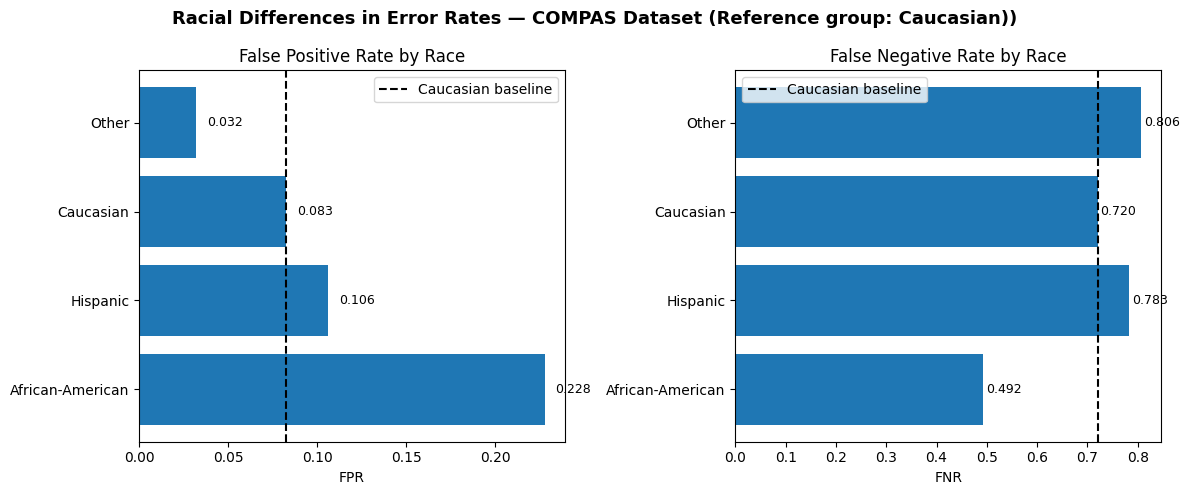

Figure saved: assn3_error_rate_disparity.png


In [52]:
er_plot = er[er['n'] >= 50].sort_values('FPR', ascending=False).copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Racial Differences in Error Rates — COMPAS Dataset (Reference group: Caucasian))',
             fontsize=13, fontweight='bold')

for ax, metric, title in [
    (axes[0], 'FPR', 'False Positive Rate by Race'),
    (axes[1], 'FNR', 'False Negative Rate by Race')
]:
    bars = ax.barh(er_plot['race'], er_plot[metric])
    baseline = er_plot.loc[er_plot['race'] == 'Caucasian', metric].values[0]
    ax.axvline(baseline, color='black', linestyle='--', label='Caucasian baseline')
    for bar, val in zip(bars, er_plot[metric]):
        ax.text(val + 0.006, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=9)
    ax.set_xlabel(metric)
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig('assn3_error_rate_disparity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: assn3_error_rate_disparity.png")

Interpretation:

The visualization highlights clear racial disparities in both false positive rates (FPR) and false negative rates (FNR) relative to the Caucasian baseline. African-American defendants exhibit a substantially higher FPR (≈ 0.228 vs. 0.083), indicating they are significantly more likely to be incorrectly classified as high risk, which may lead to disproportionately harsher outcomes. In contrast, their FNR is notably lower (≈ 0.492 vs. 0.720), meaning they are less likely to be incorrectly labeled as low risk. This reflects a systematic bias toward overestimating risk for this group.

Conversely, Hispanic and Other groups display the opposite pattern: their FPRs are closer to or lower than the baseline, but their FNRs are higher, indicating a greater likelihood of underestimating risk. Asian and Other groups have the lowest FPRs but relatively high FNRs, further emphasizing this trade-off.

Overall, the model demonstrates an imbalance in error distribution across racial groups, violating the principle of equalized odds. Rather than making uniform errors, the model disproportionately assigns false positives to African-American defendants and false negatives to other groups, suggesting that fairness concerns are deeply embedded in how risk is estimated across different populations.

# 5. Write a 300-word compliance memo addressed to a hypothetical regulator summarizing findings, metrics used, and limitations.

This memorandum summarizes the audit of a COMPAS-based risk assessment model, focusing on fairness, performance metrics, and methodological limitations. The evaluation incorporated multiple fairness and interpretability techniques, including Adverse Impact Ratio (AIR), Marginal Effect (ME), Standardized Mean Difference (SMD), and error-based metrics such as False Positive Rate (FPR) and False Negative Rate (FNR), alongside statistical validation using two-proportion z-tests.

The findings indicate the presence of significant disparities across racial groups. African-American and Native American defendants exhibit AIR values below the 0.80 threshold, signaling adverse impact under the EEOC’s four-fifths rule. These disparities are reinforced by large SMD values, suggesting systematic differences in predicted risk scores. Error-rate analysis further reveals that African-American defendants experience substantially higher false positive rates, while other groups (e.g., Hispanic and Other) exhibit higher false negative rates. These differences are statistically significant (p < 0.001), indicating that the model does not satisfy fairness criteria such as Equalized Odds.

Interpretability methods (SHAP, LIME, and DiCE) consistently identify key drivers of predictions, including age, prior offenses, and screening timing. However, they also suggest that race may influence outcomes indirectly through correlated features. Importantly, discrepancies between global (SHAP) and local (LIME) explanations highlight that model interpretation is method-dependent and not definitive.

Several limitations must be acknowledged. First, fairness metrics may conflict (e.g., equalizing FPR vs. FNR), making it impossible to satisfy all criteria simultaneously. Second, explainability tools provide approximations rather than causal insights. Third, observed disparities may partially reflect underlying data biases rather than purely model behavior.

In conclusion, while the model demonstrates predictive utility, it raises material fairness concerns. It is recommended that governance controls include continuous monitoring of disaggregated metrics, periodic bias audits, and human review for high-risk classifications, particularly for vulnerable subgroups.